# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-nyc-product-analytics-project) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 02. Exploratory Data Analysis

> "What does the NYC Airbnb market look like from both the guest and host side?"

* Before running statistical tests or building the revenue model, this notebook explores the 63,718 cleaned listings to see the shape of the data on both sides of the marketplace.

**Guest lens:** How listings are distributed across features guests actually see when booking (room type, price, Instant Book, host verification).

**Host lens:** How the market varies across boroughs, availability, and minimum-night policies that hosts control.

**Findings from this notebook support:**
* Which features get formal statistical testing in Notebook 03
* The occupancy and revenue segments explored in Notebook 04
* The review-count buckets used in Notebook 05

In [2]:
#Load saved dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)
df.head()

# Apply Airbnb branding guidelines
airbnb_coral = '#FF5A5F'  
airbnb_teal = '#00A699'   
airbnb_orange = '#FC642D' 
airbnb_dark = '#484848'   
airbnb_gray = '#767676'  

airbnb_palette = [airbnb_coral, airbnb_teal, airbnb_orange, airbnb_dark, airbnb_gray]

sns.set_palette(airbnb_palette)
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

(63718, 21)


# Section A. Guest Lens: What guests see when browsing

This section explores the features a guest actually encounters on a listing page: rating, price, whether it can be booked instantly, whether the host is verified, and what type of room it is.

## 1. Distribution of review ratings

Ratings are the primary quality signal guests see. We now look into the overall distribution to see what "typical" and "outlier" listings look like before comparing groups.

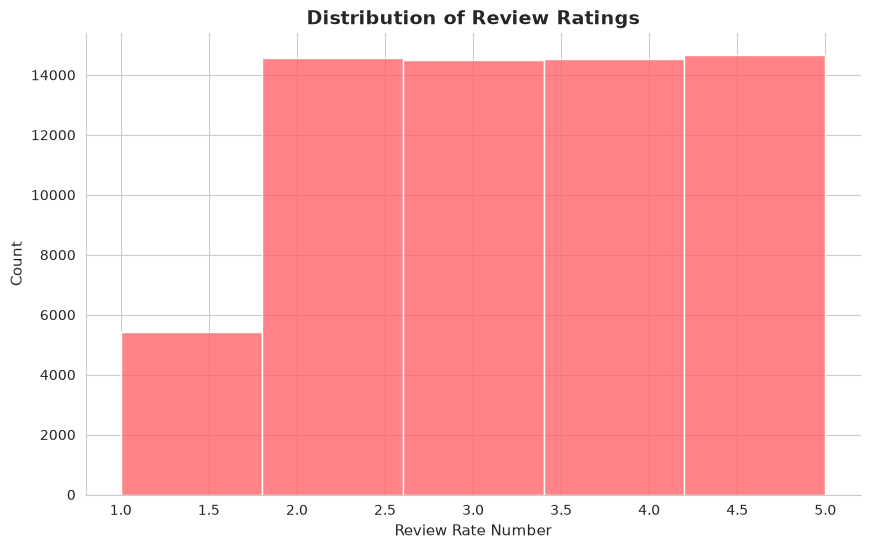

In [3]:
#Distribution of review rate number
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review rate number', bins=5)
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rate Number')
plt.ylabel('Count')
plt.show()

### Key Takeaway

* Ratings are nearly uniformly distributed from 2 to 5 stars, each holding around 14,500 listings. Only the 1-star bucket is underrepresented at roughly 5,500 listings.

* The flat distribution across 2–5 stars means the average listing is not clustered in a one specific range. Guests browsing NYC see variation in rating, which makes rating a usable filter for later statictical analysis

## 2. Price tier and rating

Price is one of the 3 guest-side features. This chart bins listings into price tiers and then looks at how average rating varies across the price bins.

In [5]:
# Bin price into tiers
df['price_tier'] = pd.cut(df['price'], 
                          bins=[0, 50, 500, 1000, 1500], 
                          labels=['Low', 'Medium', 'High', 'Very High'])


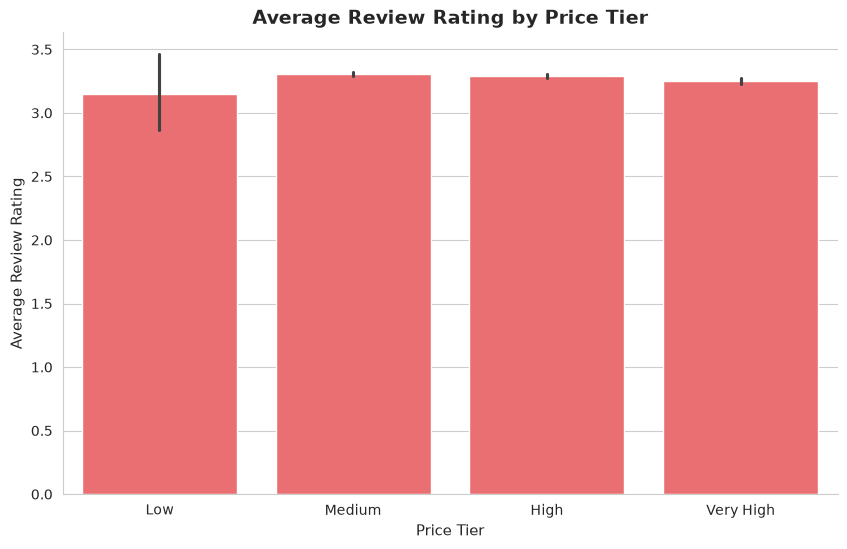

In [6]:
# Bar chart of rating by price tier
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='price_tier', y='review rate number')
plt.title('Average Review Rating by Price Tier')
plt.xlabel('Price Tier')
plt.ylabel('Average Review Rating')
plt.show()

### Key Takeaway

* Medium and High price tiers rate essentially the same at 3.3

* Very High slightly lower at 3.24, and Low at 3.15

* The Low tier also shows a much wider error bar, meaning its listings vary a lot in rating

→ **Question for Notebook 03:** Is the gap between Low and the other tiers statistically significant, or does it come from the wider variation in the Low group?

## 3. Instant Book

Instant Book is also one of the 3 guest-side features. This chart compares the rating and review activity between listings that offer it and those that do not.

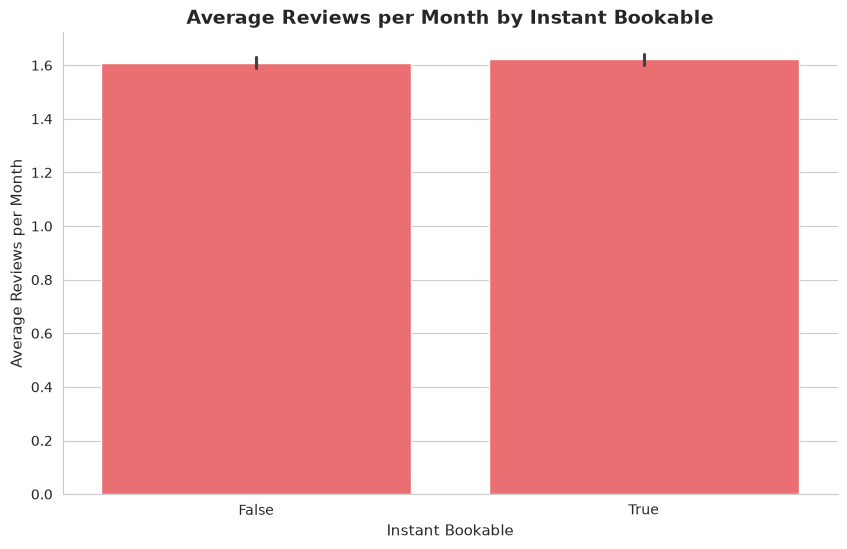

In [7]:
# Reviews per month by Instant Book status
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='instant_bookable', y='reviews per month')
plt.title('Average Reviews per Month by Instant Bookable')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Reviews per Month')
plt.show()

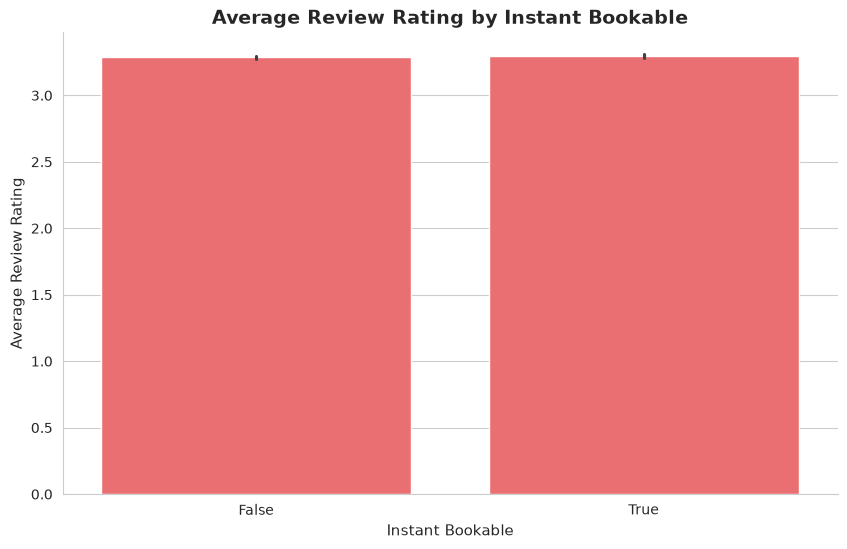

In [8]:
# Review rating by Instant Book status
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='instant_bookable', y='review rate number')
plt.title('Average Review Rating by Instant Bookable')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Review Rating')
plt.show()

### Key Takeaway

* Instant Bookable and non-Instant Bookable listings show nearly identical averages on both metrics: 3.3 stars for both groups on rating, and 1.60 reviews per month

* Error bars are tight, meaning the groups are consistent internally

→ **Question for Notebook 03:** A t-test confirms whether the gaps are statistically zero or do have a small real effect

## 4. Host verification

Host verification is the 3rd guest-side feature. This chart compares the average rating between verified and unverified hosts.

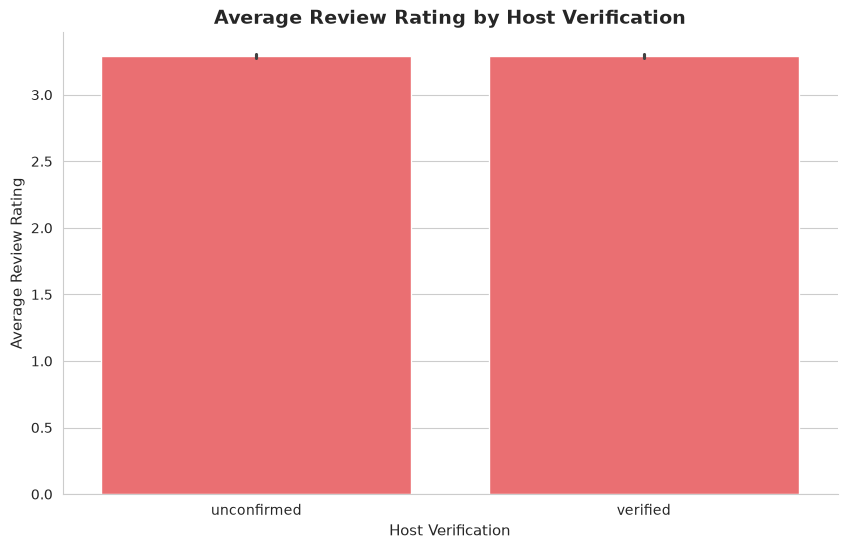

In [9]:
#Plot the figure for review rate number across host verification groups using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='host_identity_verified', y='review rate number')
plt.title('Average Review Rating by Host Verification')
plt.xlabel('Host Verification')
plt.ylabel('Average Review Rating')
plt.show()

### Key Takeaway

* Verified and unconfirmed hosts both average 3.3 stars

* The gap is essentially zero and error bars are tight

→ **Question for Notebook 03:** A t-test confirms whether verification has any measurable effect on guest ratings, though the visual gap suggests the answer is no

## 5. Room type

Room type is not one of the Q1 factors, but it is a highly visible feature on every listing page. We include it here to help frame the guest experience across the 4 room types Airbnb offers

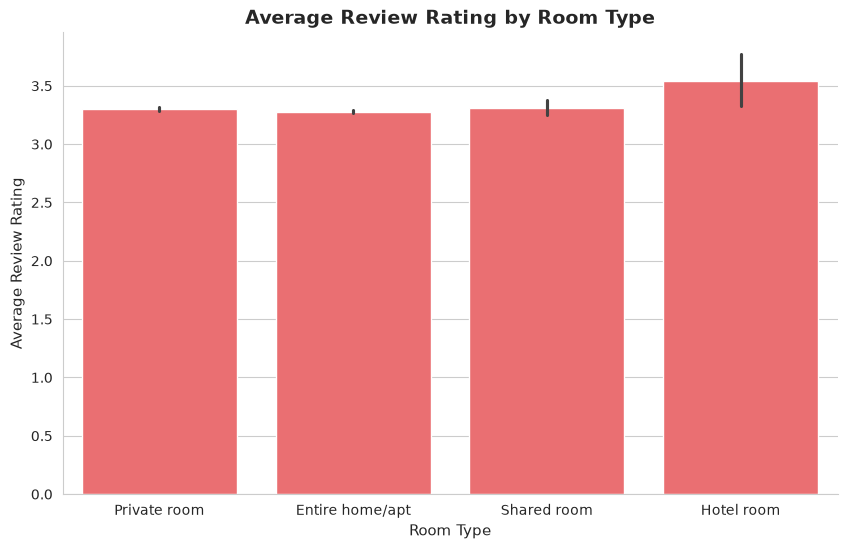

In [11]:
#Plot the figure for review rate number by room type groups using barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='room type', y='review rate number')
plt.title('Average Review Rating by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Review Rating')
plt.show()

### Key Takeaway

* Private rooms, entire homes, and shared rooms all cluster tightly around 3.28–3.31 stars

* Hotel rooms average 3.55, the highest of any room type, but with a much wider error bar, which suggests a small or uneven sample

**Note:** Room type is not one of the 3 main research questions, so we will not further test it in Notebook 03. We include it as part of the guest lens 

## Section A summary

Across the five guest-facing features:

| Feature | Visible gap |
|---|---|
| Price tier | 0.14 stars (Medium vs Low) |
| Instant Book | ~0.00 stars |
| Host verification | 0.00 stars | 
| Room type | 0.26 stars (Hotel vs Entire home) | 

→ The 3 Q1 factors all show small or zero visible gaps. Notebook 03 will test whether those gaps are real or noise through formal statistical testing

# Section B. Host Lens: How the market varies for hosts

This section shifts to the host side of the marketplac, looking at how listings are distributed across boroughs, how hosts use availability, and what minimum-night policies they set.

## 1. Listings by borough

This chart shows how the 63,718 listings split across the 5 NYC boroughs, as where hosts choose to list matters for competition, pricing, and demand.

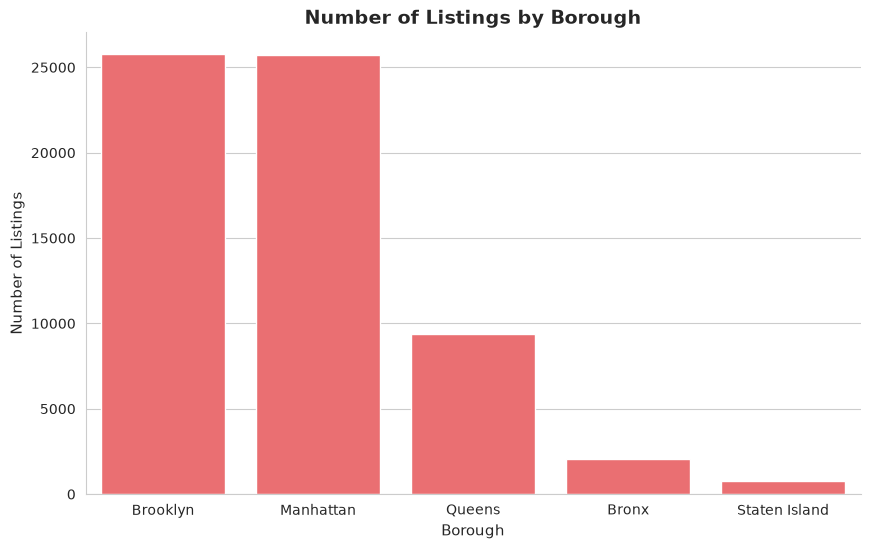

neighbourhood group
Brooklyn         25775
Manhattan        25747
Queens            9388
Bronx             2049
Staten Island      759
Name: count, dtype: int64


In [12]:
# Count of listings by borough
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='neighbourhood group', 
              order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.show()

# Print the counts for reference
print(df['neighbourhood group'].value_counts())

### Key Takeaway

* Brooklyn (25,775) and Manhattan (25,747) hold almost all the supply, followed by Queens (9,388)

* The Bronx (2,049) and Staten Island (759) are dramatically smaller

→ Our futher borough-level comparison needs to account for these sample sizes. 

→ A pattern in Staten Island is concluded on 759 listings, so it is much less reliable than a pattern in Brooklyn

## 2. Reviews per month by borough

This chart shows which boroughs see more booking activity per listing, as reviews per month is the proxy for guest demand.

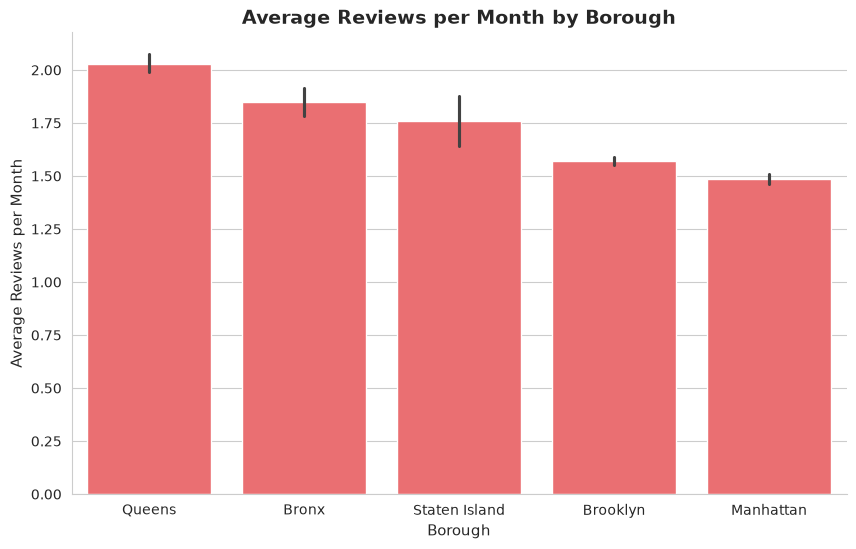

In [13]:
# Average reviews per month by borough
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='neighbourhood group', y='reviews per month',
            order=df.groupby('neighbourhood group')['reviews per month'].mean().sort_values(ascending=False).index)
plt.title('Average Reviews per Month by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Reviews per Month')
plt.show()

### Key Takeaway

* Queens leads at 2.03 reviews per month, followed by the Bronx (1.85) and Staten Island (1.76)

* Brooklyn (1.57) and Manhattan (1.49), which are the 2 largest markets, sit at the bottom.

→ **Note:** Borough-level analysis is not one of the 3 main project questions, so it is not tested further in Notebook 03. Like room type, we also include this to show that supply and per-listing demand don't always move together

## 3. Availability distribution

The distribution shows how hosts split between limited-availability and always-available strategies, availability is a host-controlled setting that shows how many days per year a listing is open for booking. 

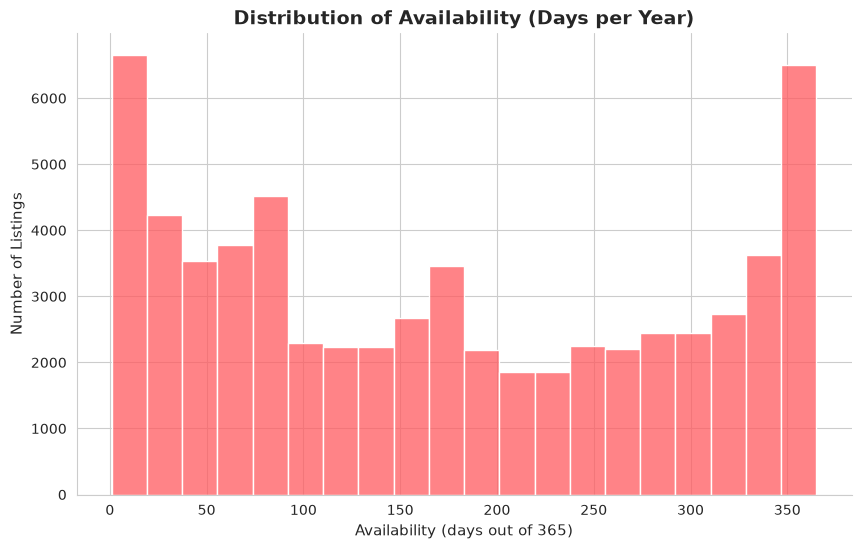

In [14]:
# Distribution of availability across 365 days
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='availability 365', bins=20)
plt.title('Distribution of Availability (Days per Year)')
plt.xlabel('Availability (days out of 365)')
plt.ylabel('Number of Listings')
plt.show()

### Key Takeaway

* The distribution spreads across the full 0–365 range, with clusters at the low end (limited availability) and high end (near always-available)

→ **Question for Notebook 04:** This split our topics for the host revenue model. Limited-availability hosts and always-available hosts will likely have different revenue and occupancy profiles.

## 4. Occupancy proxy

* Since the dataset does not include booking data, occupancy is estimated as `(365 − availability 365) / 365`

* For example, a listing with 100 days available has an occupancy proxy of 0.73, meaning 73% of the year is booked 

* This proxy is the foundation of our revenue calculation in Notebook 04

In [15]:
# Build occupancy proxy
df['occupancy_proxy'] = (365 - df['availability 365']) / 365


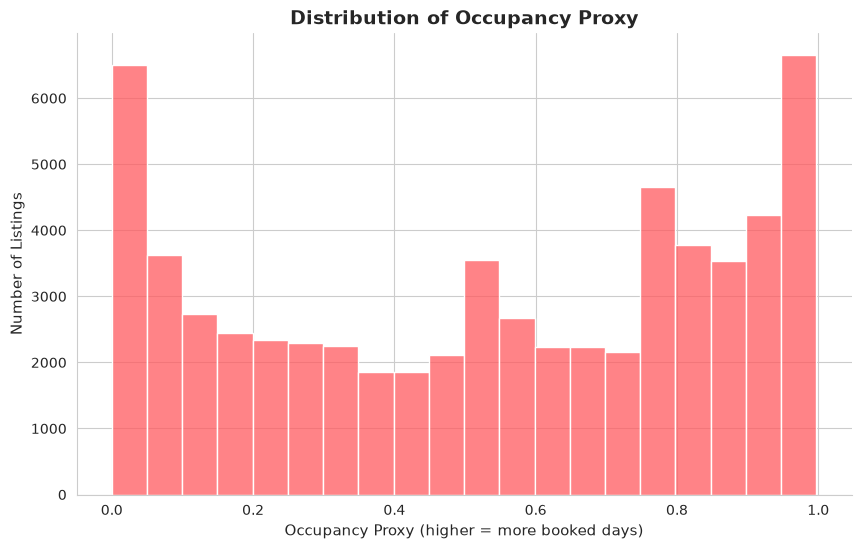

In [16]:
# Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='occupancy_proxy', bins=20)
plt.title('Distribution of Occupancy Proxy')
plt.xlabel('Occupancy Proxy (higher = more booked days)')
plt.ylabel('Number of Listings')
plt.show()

In [17]:
# Summary stats
print(df['occupancy_proxy'].describe())

count    63718.000000
mean         0.525846
std          0.329678
min          0.000000
25%          0.213699
50%          0.556164
75%          0.827397
max          0.997260
Name: occupancy_proxy, dtype: float64


### Key Takeaway 

* Occupancy proxy ranges from 0 to 0.997 with a mean of 0.53 and median of 0.56

* The interquartile range spans 0.21 to 0.83, meaning half of NYC listings show occupancy between 21% and 83% of the year

→ **Question for Notebook 04:** Which listings fall in the high-rating but low-occupancy segment? Those are the hosts missing out on revenue that could easily be earning, which is the target audience for our later AI prototype.

## 5. Minimum nights

This chart shows how the market splits between short-stay, weekly, monthly, and long-term policies. Minimum nights is another host-controlled policy that sets the shortest stay a guest can book. 

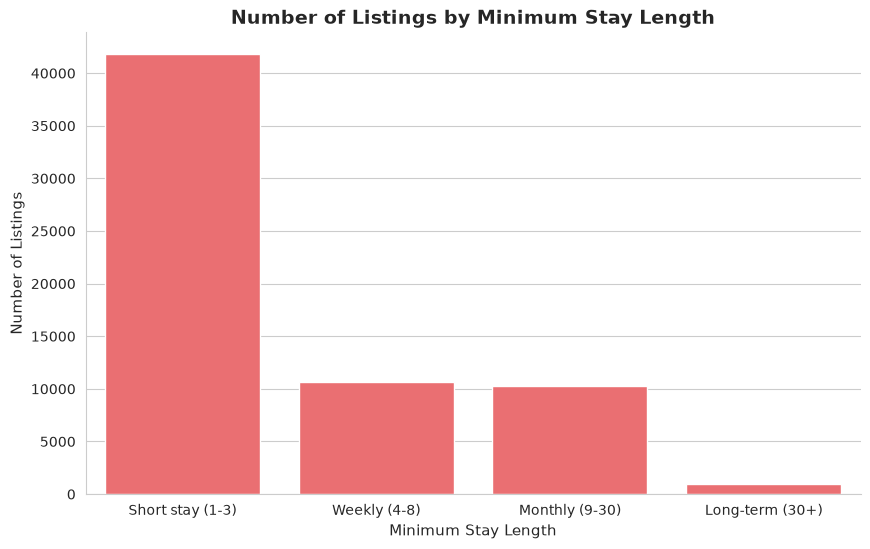

In [18]:
# Bin minimum nights into policy tiers
df['stay_length'] = pd.cut(df['minimum nights'],
                           bins=[0, 3, 8, 30, 2645],
                           labels=['Short stay (1-3)', 'Weekly (4-8)', 'Monthly (9-30)', 'Long-term (30+)'])

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='stay_length')
plt.title('Number of Listings by Minimum Stay Length')
plt.xlabel('Minimum Stay Length')
plt.ylabel('Number of Listings')
plt.show()

### Key Takeaway 

* Most listings offer short stays (1–3 nights), with a meaningful chunk in the weekly and monthly range.Long-term policies are much rarer.

→ **Note:** Similar to room type and borough-level analysis, minimum nights is not one of our  3 main questions, so it is not tested further. It is included to show that most NYC listings are optimized for short-stay tourism, which sets the baseline against which the Notebook 04 revenue model runs.

### Section B summary

| Feature | What it tells us |
|---|---|
| Borough supply | Brooklyn and Manhattan dominate, while Bronx and Staten Island are small | 
| Borough demand | Queens leads on reviews per month | 
| Availability | Wide spread, and hosts split between limited and always-available | 
| Occupancy proxy | A large low-occupancy group and a large high-occupancy group | 
| Minimum nights | Market skews heavily to short stays | 

→ The availability and occupancy findings set up our revenue model in Notebook 04, while the others are better understanding of the context.

# Section C. Handoff to Notebooks 03, 04, and 05

The EDA above raises 3 questions that my next notebooks answer through analysis.

**1. Do the guest-side features actually predict rating or booking activity?**

Price tier, Instant Book, and host verification all show small visible gaps in Section A. We will conduct statistical testing (t-tests and ANOVA) to confirm whether these gaps are real or noise.

→ **Notebook 03: Guest Decision Drivers**

**2. Where does additional review count stop influencing booking activity?**

Section A did not explore review count as a signal on its own. This is the second Q1 guest-side question and gets its own notebook because of the binning and comparison work involved.

→ **Notebook 05: Review Count Curve**

**3. Which highly-rated listings show low occupancy, and how much revenue is unused?**

Section B built the occupancy proxy and showed that half of NYC listings sit between 21% and 83% occupancy. We will therefore combine occupancy with rating and price to isolate the high-rated, low-occupancy segment, which is the target audience for the AI prototype.

→ **Notebook 04: Host Revenue Model**